In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#Import Database
df = pd.read_excel("dataset250326.xlsx")

In [ ]:
#Melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2964 entries, 0 to 2965
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Delivery   2964 non-null   int64         
 1   Material   2964 non-null   object        
 2   Stok       2964 non-null   int64         
 3   Date       2964 non-null   datetime64[ns]
 4   Qty        2964 non-null   int64         
 5   Price      2961 non-null   float64       
 6   Net Sales  2961 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 185.2+ KB


In [ ]:
#Melihat deskripsi dataset
df.describe()

,Delivery,Stok,Date,Qty,Price,Net Sales
count,2.966000e+03,2966.000000,2966,2966.000000,2963.000000,2.963000e+03
mean,2.508258e+07,6783.335131,2024-07-01 19:59:40.579905792,5275.930546,36209.812015,1.764345e+08
min,2.505783e+07,206.000000,2023-01-02 00:00:00,160.000000,10196.000000,2.518080e+06
25%,2.505839e+07,868.500000,2023-09-25 00:00:00,675.500000,25250.000000,1.836730e+07
50%,2.505900e+07,3099.000000,2024-07-01 00:00:00,2410.000000,31923.000000,8.043840e+07
75%,2.505967e+07,5924.500000,2025-03-31 00:00:00,4607.750000,44688.000000,1.969700e+08
max,3.500004e+07,50914.000000,2025-12-29 00:00:00,39600.000000,73791.000000,1.146103e+09
std,4.824511e+05,10614.663736,NaN,8255.847233,17672.622232,2.548774e+08


In [ ]:
#Melihat data mana yang duplikat
duplicates = df[df.duplicated()]
print(duplicates)

     Delivery       Material   Stok       Date   Qty    Price    Net Sales
219  25058040   NL-7442D-A00  10403 2023-03-20  8091  31835.0  257576985.0
86   25057882  SW-0506AS-A00   1765 2023-01-30  1373  10196.0   13999108.0


In [ ]:
#Menghapus data yang duplikat
df = df.drop_duplicates()

In [ ]:
#Melihat data yang duplikat setelah dihapus
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Delivery, Material, Stok, Date, Qty, Price, Net Sales]
Index: []


In [ ]:
#Melihat struktur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2964 entries, 0 to 2965
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Delivery   2964 non-null   int64         
 1   Material   2964 non-null   object        
 2   Stok       2964 non-null   int64         
 3   Date       2964 non-null   datetime64[ns]
 4   Qty        2964 non-null   int64         
 5   Price      2961 non-null   float64       
 6   Net Sales  2961 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 185.2+ KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values(['Material','Date'])

df.head()


#tampilkan total baris / data

,Delivery,Material,Stok,Date,Qty,Price,Net Sales
0,25057853,MI-7672D-A01,2555,2023-01-02,1987,30264.0,60134568.0
19,25057838,MI-7672D-A01,2552,2023-01-09,1985,30264.0,60074040.0
38,25057837,MI-7672D-A01,2597,2023-01-16,2020,30264.0,61133280.0
57,25057852,MI-7672D-A01,2679,2023-01-23,2084,30264.0,63070176.0
76,25057903,MI-7672D-A01,2596,2023-01-30,2019,30264.0,61103016.0


In [ ]:
df_clean = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2966 entries, 0 to 2965
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   No         2966 non-null   int64         
 1   Delivery   2966 non-null   int64         
 2   Material   2966 non-null   object        
 3   Stok       2966 non-null   int64         
 4   Date       2966 non-null   datetime64[ns]
 5   Qty        2966 non-null   int64         
 6   Price      2963 non-null   float64       
 7   Net Sales  2963 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 208.5+ KB


In [ ]:
#Setting parameter window
window = 4


In [ ]:
#Membuat Sequence
def create_sequence(data, window):

    X = []
    y = []

    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])

    return np.array(X), np.array(y)

In [ ]:
#Melihat berapa banyak varian produk
products = df['Material'].unique()

print("Total produk:", len(products))

Total produk: 19


In [ ]:
#Split Data - Data Training
results = []

for product in products:

    print("Training:", product)

    data = df[df['Material']==product].sort_values('Date')

    qty = data['Qty'].values.reshape(-1,1)

    split = int(len(qty)*0.7)

    train_qty = qty[:split]
    test_qty = qty[split:]

    # skip jika data terlalu sedikit
    if len(train_qty) < window+1 or len(test_qty) < window+1:
        continue

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train_qty)
    test_scaled = scaler.transform(test_qty)

    X_train, y_train = create_sequence(train_scaled, window)
    X_test, y_test = create_sequence(test_scaled, window)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1],1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1],1))

Training: MI-7672D-A01
Training: MI-7672K-A00
Training: MI-7672V-A00
Training: NL-7421AE-A00
Training: NL-7421AK-A00
Training: NL-7421O-A00
Training: NL-7442-A00
Training: NL-7442A-A00
Training: NL-7442D-A00
Training: SW-0506AS-A00
Training: SW-0506BD-A00
Training: SW-0507BM-A00
Training: SW-0520AN-A00
Training: SW-0570D-A00
Training: SW-0639AG-A00
Training: SW-0640AV-A00
Training: SW-0657BE-A00
Training: SW-0966B-A00
Training: SW-0966D-A00


In [ ]:
#Membangun Model LSTM
#1. Layer input + Jumlah Neuron + Array
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(window,1)))

#2. Hidden Layer
model.add(Dropout(0.2))
model.add(LSTM(32))

#3. Output Layer
model.add(Dense(1))

#4. Model Compile
model.compile(
    optimizer='adam',
    loss='mean_absolute_percentage_error'
  )
#5. Melatih Model
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=16,
        verbose=1,
        callbacks=[early_stopping]
    )
#6. Melakukan prediksi pada data testing
pred = model.predict(X_test)
pred_actual = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 431272.3438
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 244944.1094 
Epoch 3/50
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 107.4125

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 600698.6875
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 405408.8750
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 208375.9219 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 239256.7812
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 275207.4062 
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13370.6445
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 58167.7969
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 116855.4766
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 85401.8672
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4377.6362
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 418060.1562
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 320761.9688
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 89064.8203
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 75957.4062 
Epoch 17/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16

In [ ]:
# Loop untuk testing

results = []

predictions_dict = {}

testing_rows = []

for product in products:

    print("Training:", product)

    data = df[df['Material']==product].sort_values('Date')

    qty = data['Qty'].values.reshape(-1,1)

    split = int(len(qty)*0.7)

    train_qty = qty[:split]
    test_qty = qty[split:]
    test_dates = data['Date'].iloc[split:]

    scaler = MinMaxScaler()

    train_scaled = scaler.fit_transform(train_qty)
    test_scaled = scaler.transform(test_qty)

    X_train, y_train = create_sequence(train_scaled, window)
    X_test, y_test = create_sequence(test_scaled, window)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1],1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1],1))

    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(window,1)))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    pred = model.predict(X_test)

    pred_actual = scaler.inverse_transform(pred)
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

    dates = test_dates.iloc[window:].reset_index(drop=True)

    for i in range(len(pred_actual)):

        actual_val = float(y_test_actual[i])
        pred_val = float(pred_actual[i])

        error = pred_val - actual_val
        mape_row = abs(error) / actual_val * 100

        testing_rows.append({
            "Tanggal": dates.iloc[i],
            "Nama Produk": product,
            "Qty Jual": actual_val,
            "Qty Prediksi": pred_val,
            "Selisih Prediksi": error,
            "MAPE (%)": mape_row
        })


  # SIMPAN HASIL PREDIKSI PRODUK INI
    predictions_dict[product] = {
        "actual": y_test_actual.flatten(),
        "pred": pred_actual.flatten(),
        "dates": test_dates.iloc[window:].reset_index(drop=True)
    }
    mape = mean_absolute_percentage_error(y_test_actual, pred_actual)*100

    wape = np.sum(np.abs(y_test_actual - pred_actual)) / np.sum(y_test_actual) * 100


    results.append({
        "Produk": product,
        "MAPE (%)": mape,
        "WAPE (%)": wape
    })

Training: MI-7672D-A01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step
Training: MI-7672K-A00


/tmp/ipykernel_999/1109648762.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_val = float(y_test_actual[i])
/tmp/ipykernel_999/1109648762.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_val = float(pred_actual[i])
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step

...

/tmp/ipykernel_999/1109648762.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_val = float(y_test_actual[i])
/tmp/ipykernel_999/1109648762.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_val = float(pred_actual[i])
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step
Training: SW-0966D-A00


/tmp/ipykernel_999/1109648762.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_val = float(y_test_actual[i])
/tmp/ipykernel_999/1109648762.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_val = float(pred_actual[i])
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 482ms/step


/tmp/ipykernel_999/1109648762.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual_val = float(y_test_actual[i])
/tmp/ipykernel_999/1109648762.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_val = float(pred_actual[i])


In [ ]:
print(len(results))

19


In [ ]:
#Melihat hasil MAPE
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("MAPE (%)")

results_df

,Produk,MAPE (%),WAPE (%)
3,NL-7421AE-A00,1.756951,1.762979
17,SW-0966B-A00,1.814719,1.913479
6,NL-7442-A00,2.607774,2.584847
1,MI-7672K-A00,2.842087,2.848231
2,MI-7672V-A00,3.314167,3.307116
18,SW-0966D-A00,3.423031,3.397415
8,NL-7442D-A00,3.616219,3.582110
5,NL-7421O-A00,3.871248,3.857750
14,SW-0639AG-A00,4.799198,4.911803
15,SW-0640AV-A00,5.477682,5.330763


In [ ]:
#Melihat produk mana dengan akurasi terbaik dan terburuk
best_product = results_df.iloc[0]
worst_product = results_df.iloc[-1]

print("Produk dengan akurasi terbaik:")
print(best_product)

print("\nProduk dengan akurasi terburuk:")
print(worst_product)

Produk dengan akurasi terbaik:
Produk      NL-7421AE-A00
MAPE (%)         1.756951
WAPE (%)         1.762979
Name: 3, dtype: object

Produk dengan akurasi terburuk:
Produk      MI-7672D-A01
MAPE (%)       22.932337
WAPE (%)        9.399112
Name: 0, dtype: object


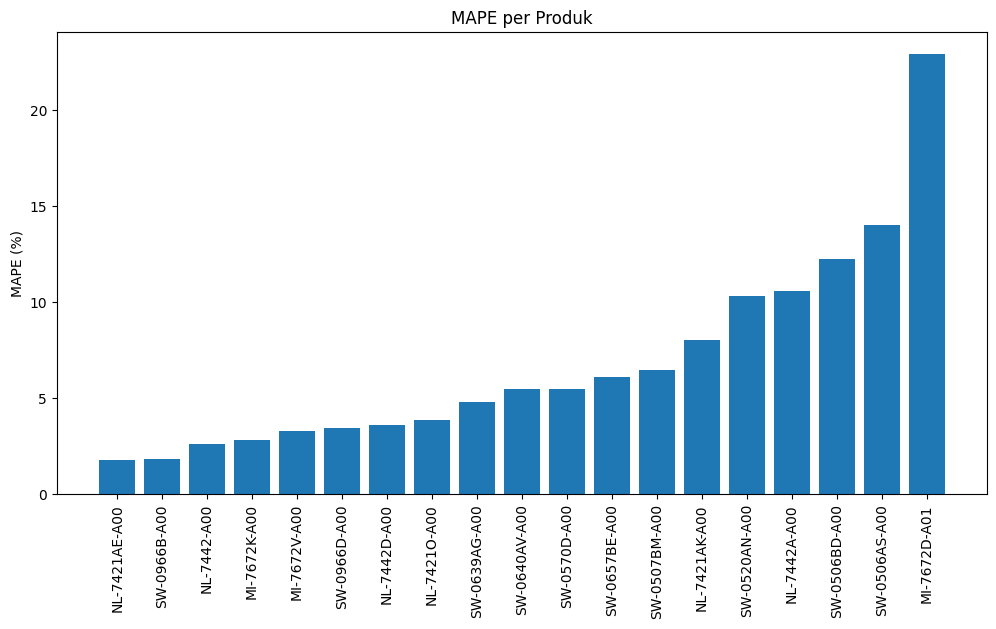

In [ ]:
#Visualisasi MAPE per produk
plt.figure(figsize=(12,6))

plt.bar(results_df["Produk"], results_df["MAPE (%)"])

plt.xticks(rotation=90)

plt.title("MAPE per Produk")

plt.ylabel("MAPE (%)")

plt.show()

In [ ]:
#Deklarasi untuk grafik keseluruhan
all_actual = []
all_pred = []
product_names = []

for product in results_df["Produk"]:

    actual = predictions_dict[product]["actual"]
    pred = predictions_dict[product]["pred"]

    # ambil rata-rata atau total (biasanya rata-rata untuk grafik seperti contoh)
    all_actual.append(np.mean(actual))
    all_pred.append(np.mean(pred))

    product_names.append(product)

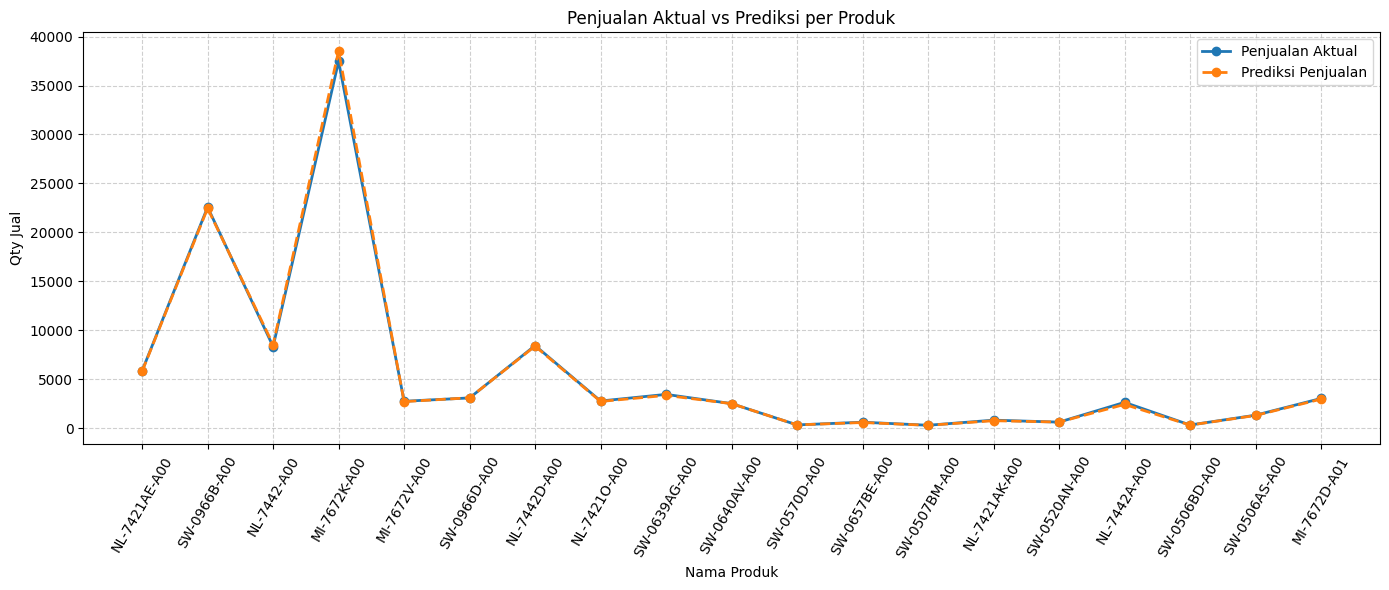

In [ ]:
#Visualisasi Grafik Keseluruhan
plt.figure(figsize=(14,6))

plt.plot(product_names, all_actual,
         marker='o',
         label="Penjualan Aktual",
         linewidth=2)

plt.plot(product_names, all_pred,
         marker='o',
         linestyle='--',
         label="Prediksi Penjualan",
         linewidth=2)

plt.title("Penjualan Aktual vs Prediksi per Produk")

plt.xlabel("Nama Produk")
plt.ylabel("Qty Jual")

plt.xticks(rotation=60)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
#Deklarasi variabel produk terbaik dan terburuk
best_name = best_product["Produk"]

actual = predictions_dict[best_name]["actual"]
pred = predictions_dict[best_name]["pred"]
dates = predictions_dict[best_name]["dates"]

In [ ]:
#Tampilan tabel perbandingan produk terbaik
comparison_df = pd.DataFrame({
    "Tanggal": dates,
    "Qty Aktual": actual,
    "Qty Prediksi": pred
})

comparison_df

,Tanggal,Qty Aktual,Qty Prediksi
0,2025-03-10,5570.0,5603.407715
1,2025-03-17,5600.0,5611.402344
2,2025-03-24,5900.0,5551.309570
3,2025-03-31,5780.0,5627.101562
4,2025-04-07,5480.0,5672.773438
5,2025-04-14,5600.0,5697.466797
6,2025-04-21,5650.0,5703.484375
7,2025-04-28,5590.0,5615.273438
8,2025-05-05,5680.0,5559.572754
9,2025-05-12,5700.0,5610.348145


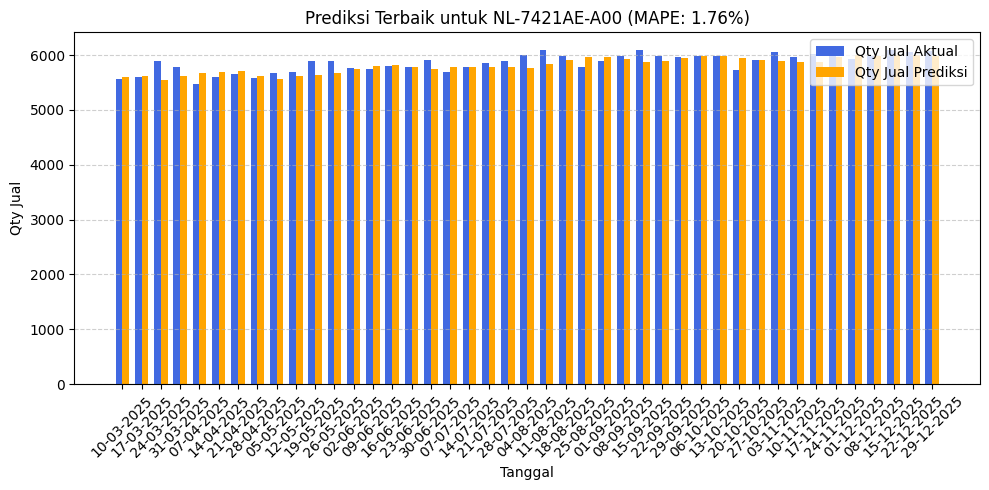

In [ ]:
#Visualisasi Produk dengan akurasi terbaik
x = np.arange(len(comparison_df["Tanggal"]))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2,
        comparison_df["Qty Aktual"],
        width,
        label="Qty Jual Aktual",
        color="royalblue")

plt.bar(x + width/2,
        comparison_df["Qty Prediksi"],
        width,
        label="Qty Jual Prediksi",
        color="orange")

plt.xticks(x,
           comparison_df["Tanggal"].dt.strftime('%d-%m-%Y'),
           rotation=45)

plt.title(f"Prediksi Terbaik untuk {best_name} (MAPE: {best_product['MAPE (%)']:.2f}%)")

plt.xlabel("Tanggal")
plt.ylabel("Qty Jual")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
#Produk dengan akurasi terendah
worst_product = results_df.iloc[-1]
worst_name = worst_product["Produk"]

print("Produk dengan akurasi terburuk:", worst_name)
print("MAPE:", worst_product["MAPE (%)"])

Produk dengan akurasi terburuk: MI-7672D-A01
MAPE: 22.932336793824952


In [ ]:
#Tampilan tabel produk MAPE terburuk
actual_worst = predictions_dict[worst_name]["actual"]
pred_worst = predictions_dict[worst_name]["pred"]
dates_worst = predictions_dict[worst_name]["dates"]

comparison_df_worst = pd.DataFrame({
    "Tanggal": dates_worst,
    "Qty Aktual": actual_worst,
    "Qty Prediksi": pred_worst
})

comparison_df_worst

,Tanggal,Qty Aktual,Qty Prediksi
0,2025-03-10,3040.0,3064.854004
1,2025-03-17,3220.0,3091.821045
2,2025-03-24,3140.0,3082.931641
3,2025-03-31,660.0,3064.838867
4,2025-04-07,600.0,2826.941895
5,2025-04-14,2740.0,2419.684570
6,2025-04-21,2740.0,1980.283447
7,2025-04-28,2880.0,1634.552856
8,2025-05-05,2991.0,2117.091553
9,2025-05-12,2860.0,2783.065918


In [ ]:
#Tabel dengan produk akurasi terburuk
actual_worst = predictions_dict[worst_name]["actual"]
pred_worst = predictions_dict[worst_name]["pred"]
dates_worst = predictions_dict[worst_name]["dates"]



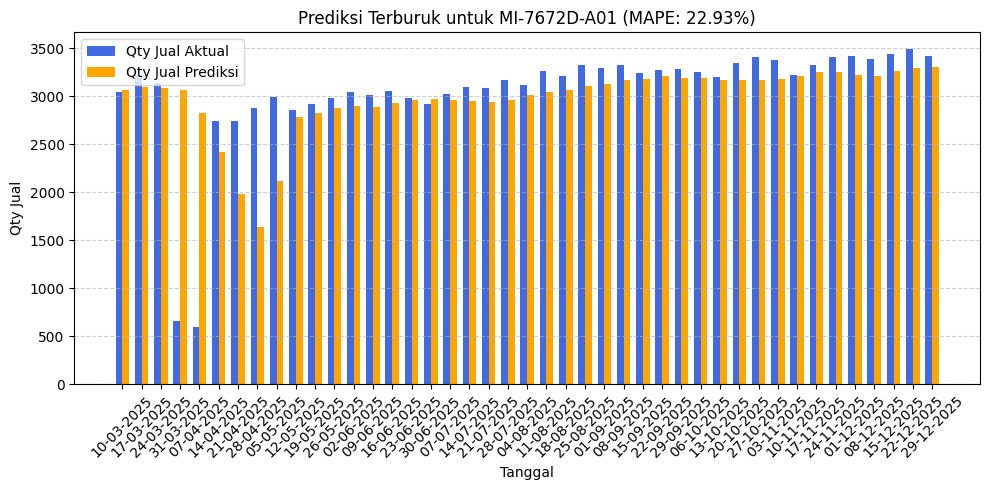

In [ ]:
#Pembuatan grafik akurasi terburuk
x = np.arange(len(comparison_df_worst["Tanggal"]))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2,
        comparison_df_worst["Qty Aktual"],
        width,
        label="Qty Jual Aktual",
        color="royalblue")

plt.bar(x + width/2,
        comparison_df_worst["Qty Prediksi"],
        width,
        label="Qty Jual Prediksi",
        color="orange")

plt.xticks(x,
           comparison_df_worst["Tanggal"].dt.strftime('%d-%m-%Y'),
           rotation=45)

plt.title(f"Prediksi Terburuk untuk {worst_name} (MAPE: {worst_product['MAPE (%)']:.2f}%)")

plt.xlabel("Tanggal")
plt.ylabel("Qty Jual")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()

plt.show()

In [ ]:
#Tren penjualan namun mingguan
df_weekly = df.copy()

df_weekly["Tanggal"] = pd.to_datetime(df_weekly["Date"])

df_weekly = df_weekly.groupby("Tanggal")["Qty"].sum().reset_index()

In [ ]:
testing_table = pd.DataFrame(testing_rows)

testing_table = testing_table.sort_values(["Tanggal","Nama Produk"])

testing_table.head()

,Tanggal,Nama Produk,Qty Jual,Qty Prediksi,Selisih Prediksi,MAPE (%)
0,2025-03-10,MI-7672D-A01,3040.0,3064.854004,24.854004,0.817566
43,2025-03-10,MI-7672K-A00,35650.0,36870.003906,1220.003906,3.422171
86,2025-03-10,MI-7672V-A00,2390.0,2378.328125,-11.671875,0.488363
129,2025-03-10,NL-7421AE-A00,5570.0,5603.407715,33.407715,0.599779
172,2025-03-10,NL-7421AK-A00,795.0,739.323914,-55.676086,7.003281


In [ ]:
# aktual 2024
#actual_2024 = df_weekly[df_weekly["Tanggal"].dt.year == 2024]

# prediksi untuk periode yang sama
#pred_weekly = testing_table.groupby("Tanggal")["Qty Prediksi"].sum().reset_index()

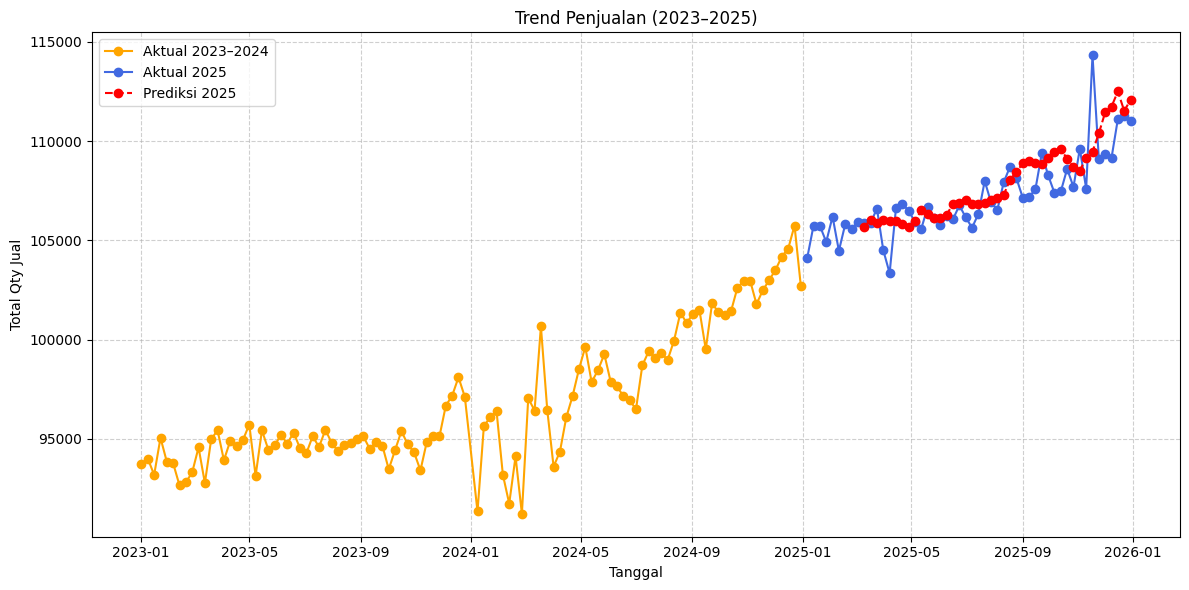

In [ ]:
#PLOT VISUALISASI
df_weekly["Tanggal"] = pd.to_datetime(df_weekly["Tanggal"])
pred_weekly["Tanggal"] = pd.to_datetime(pred_weekly["Tanggal"])

# 1. Data historis 2023–2024
actual_2023_2024 = df_weekly[df_weekly["Tanggal"].dt.year.isin([2023, 2024])]

# 2. Aktual 2025
actual_2025 = df_weekly[df_weekly["Tanggal"].dt.year == 2025]

# 3. Prediksi 2025
pred_2025 = pred_weekly[pred_weekly["Tanggal"].dt.year == 2025]

plt.figure(figsize=(12,6))

# Hijau: aktual 2023–2024
plt.plot(actual_2023_2024["Tanggal"],
         actual_2023_2024["Qty"],
         color="orange",
         marker="o",
         label="Aktual 2023–2024")

# Biru: aktual 2025
plt.plot(actual_2025["Tanggal"],
         actual_2025["Qty"],
         color="royalblue",
         marker="o",
         label="Aktual 2025")

# Merah: prediksi 2025
plt.plot(pred_2025["Tanggal"],
         pred_2025["Qty Prediksi"],
         color="red",
         linestyle="--",
         marker="o",
         label="Prediksi 2025")

plt.title("Trend Penjualan (2023–2025)")
plt.xlabel("Tanggal")
plt.ylabel("Total Qty Jual")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
all_actual = []
all_pred = []
product_names = []

for product in results_df["Produk"]:

    actual = predictions_dict[product]["actual"]
    pred = predictions_dict[product]["pred"]

    # ambil rata-rata atau total (biasanya rata-rata untuk grafik seperti contoh)
    all_actual.append(np.mean(actual))
    all_pred.append(np.mean(pred))

    product_names.append(product)

In [ ]:
testing_table = pd.DataFrame(testing_rows)

testing_table = testing_table.sort_values(["Tanggal","Nama Produk"])

testing_table.head()

,Tanggal,Nama Produk,Qty Jual,Qty Prediksi,Selisih Prediksi,MAPE (%)
0,2025-03-10,MI-7672D-A01,3040.0,3064.854004,24.854004,0.817566
43,2025-03-10,MI-7672K-A00,35650.0,36870.003906,1220.003906,3.422171
86,2025-03-10,MI-7672V-A00,2390.0,2378.328125,-11.671875,0.488363
129,2025-03-10,NL-7421AE-A00,5570.0,5603.407715,33.407715,0.599779
172,2025-03-10,NL-7421AK-A00,795.0,739.323914,-55.676086,7.003281


In [ ]:
testing_table.to_excel("comparison_testing.xlsx", index=False)

In [ ]:
#Heatmap / Korelasi - Ambil fitur yang akan digunakan
features = df[["Price", "Net Sales", "Stok", "Qty"]]

In [ ]:
corr_matrix = features.corr()
corr_matrix

,Price,Net Sales,Stok,Qty
Price,1.000000,-0.001196,-0.100455,-0.100456
Net Sales,-0.001196,1.000000,0.986751,0.986751
Stok,-0.100455,0.986751,1.000000,1.000000
Qty,-0.100456,0.986751,1.000000,1.000000


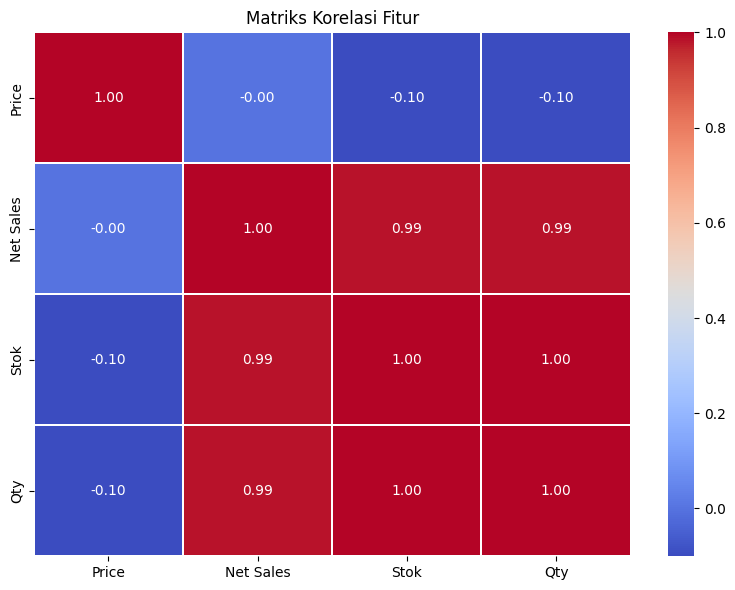

In [ ]:
#Visualisasi matriks korelasi
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.2)

plt.title("Matriks Korelasi Fitur")

plt.tight_layout()
plt.show()